(1309, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  


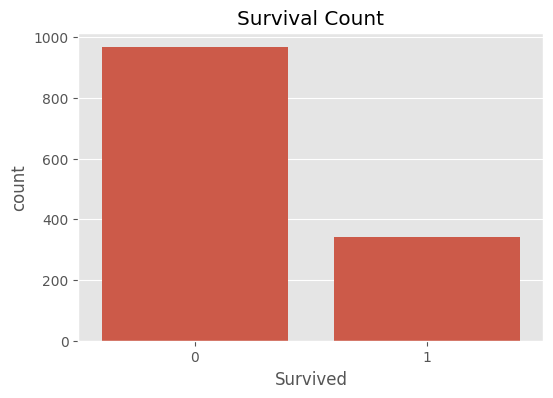

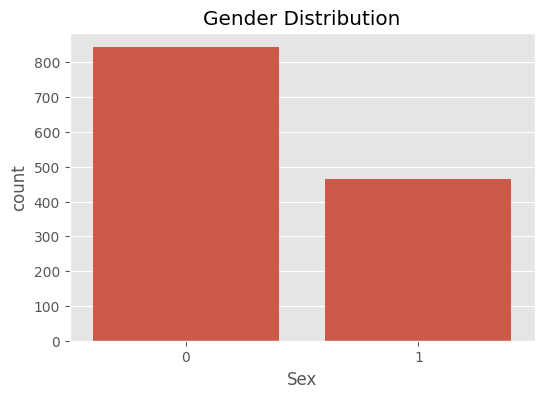

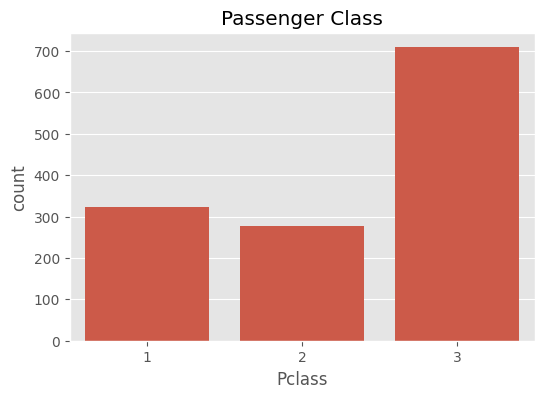

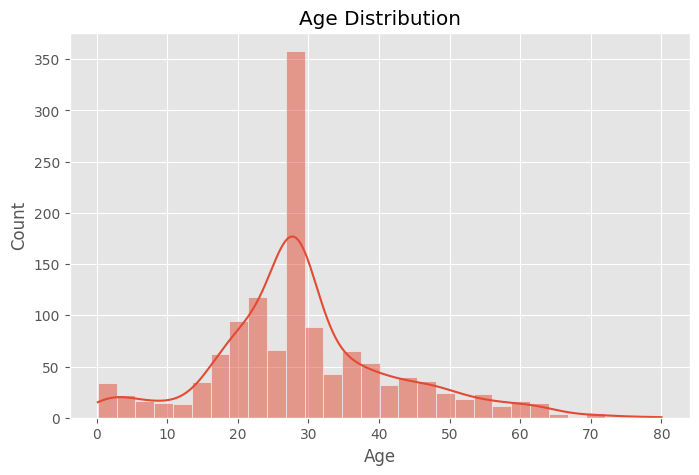

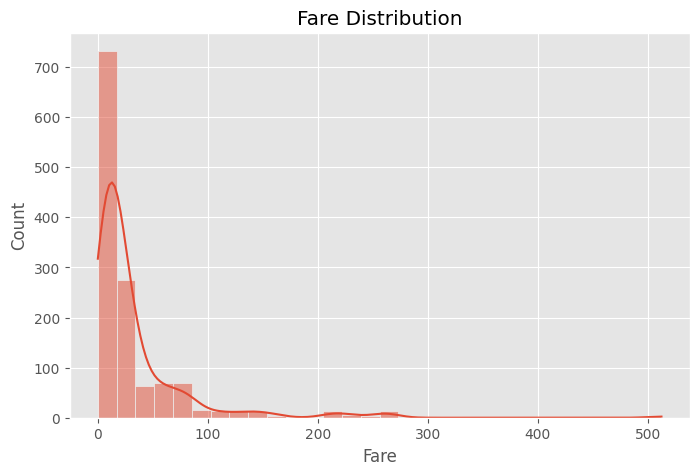

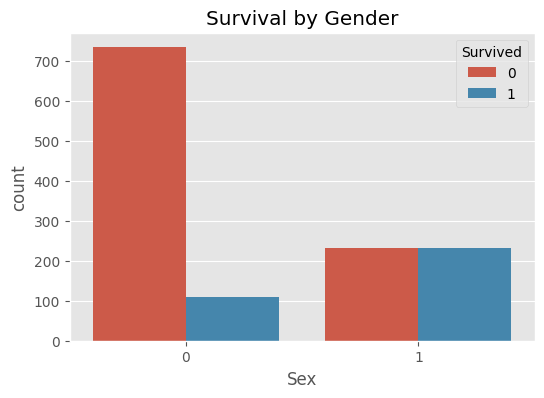

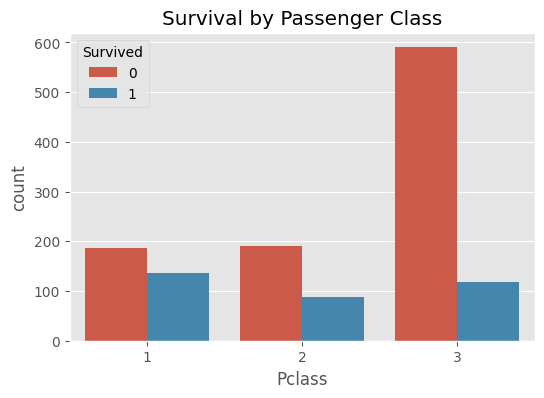

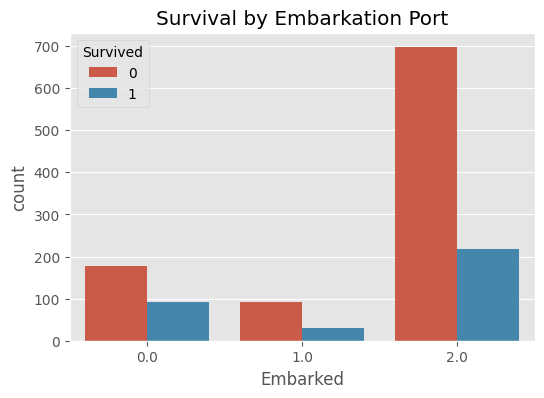

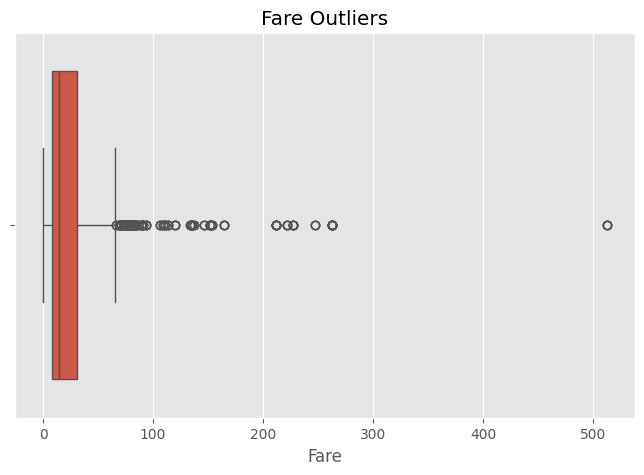

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline
df = pd.read_csv("train.csv")

df.head()
print(df.shape)
df.columns
df.info()
df.describe()
df.isnull().sum()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.rename(columns={"2urvived": "Survived"}, inplace=True) # Added this line
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Survived")

plt.title("Survival Count")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Sex")

plt.title("Gender Distribution")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Pclass")

plt.title("Passenger Class")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(df["Age"],bins=30,kde=True)

plt.title("Age Distribution")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(df["Fare"],bins=30,kde=True)

plt.title("Fare Distribution")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Sex",hue="Survived")

plt.title("Survival by Gender")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Pclass",hue="Survived")

plt.title("Survival by Passenger Class")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Embarked",hue="Survived")

plt.title("Survival by Embarkation Port")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()


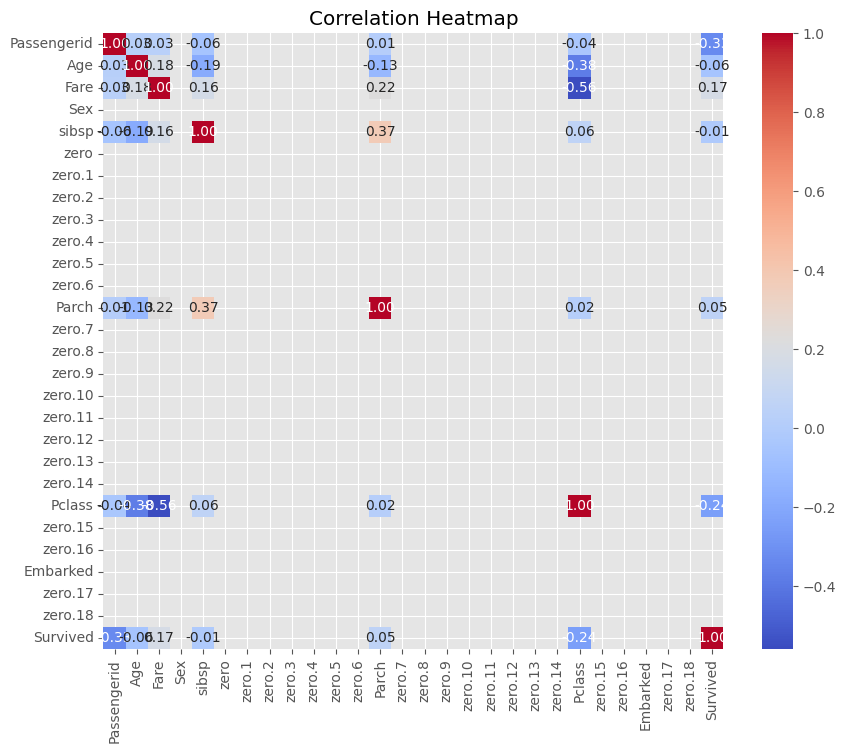

In [45]:
df_corr = df.copy()

df_corr["Sex"] = df_corr["Sex"].map({"male":0,"female":1})

df_corr["Embarked"] = df_corr["Embarked"].map({"S":0,"C":1,"Q":2})
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

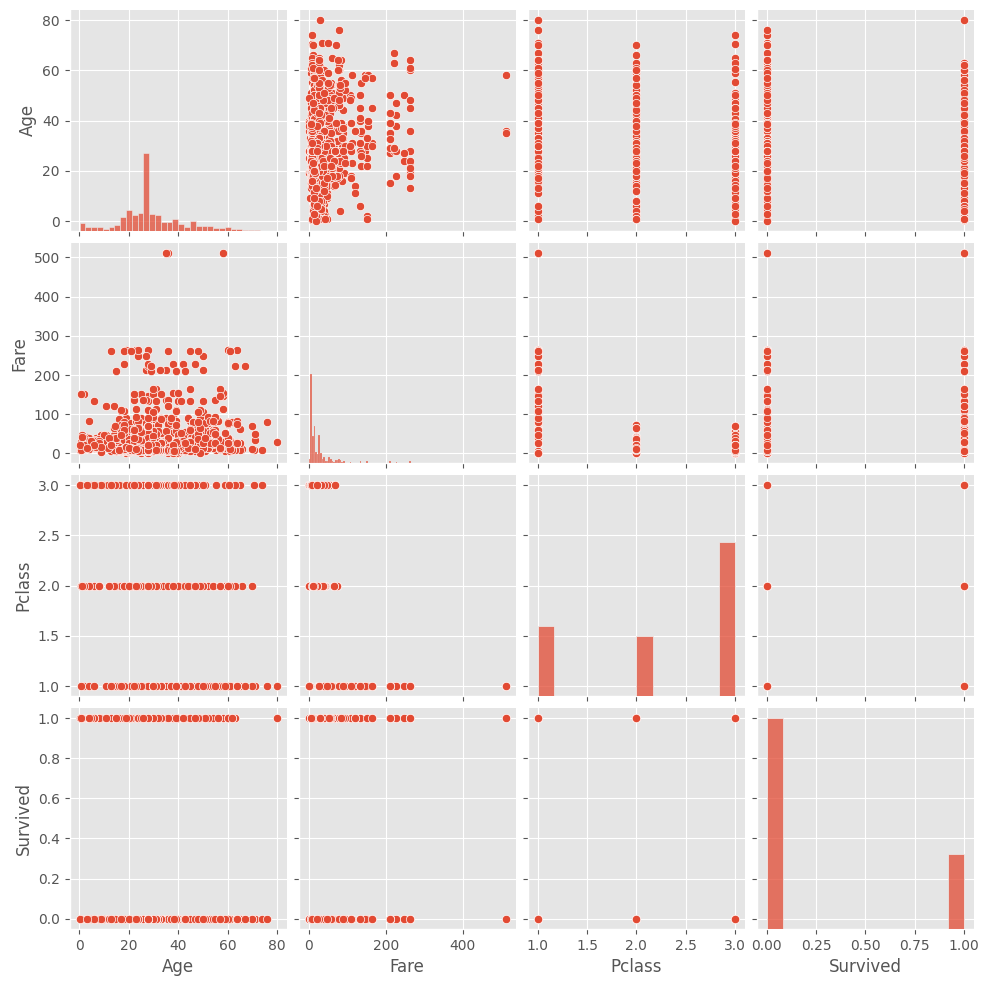

In [46]:
sns.pairplot(df[["Age","Fare","Pclass","Survived"]])

plt.show()